# EDA — SSH Anomaly Detection

Notebook này tổng hợp quá trình khám phá dữ liệu (Exploratory Data Analysis) của project,
từ raw log thô đến dataset sạch sẵn sàng cho ML training.

**Luồng phân tích:**
1. Khám phá file log thô (`SSH.log`)
2. Phát hiện class imbalance cực độ (99.9% anomaly)
3. Sửa lỗi parser (message repeated, cross-year timestamp)
4. Session-level aggregation + Multi-level labeling
5. Tinh chỉnh ngưỡng gán nhãn (Scan, Break-in, Brute-force streak)
6. Feature engineering & đánh giá dataset cuối cùng

In [1]:
import sys
sys.path.insert(0, '../src')

import re
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

RAW_LOG = Path('../data/raw/SSH.log')
SESSION_CSV = Path('../data/processed/ssh_sessions.csv')

---
## 1. Khám phá file log thô

File `SSH.log` là auth log của máy chủ `LabSZ`, ghi nhận toàn bộ hoạt động SSH
trong khoảng **28 ngày** (Dec 10 → Jan 7).

In [2]:
# Đếm tổng dòng và phân loại event
event_patterns = {
    'Accepted password': 0,
    'Failed password': 0,
    'Invalid user': 0,
    'message repeated': 0,
    'POSSIBLE BREAK-IN ATTEMPT': 0,
    'Too many authentication': 0,
    'Did not receive identification': 0,
    'Connection closed': 0,
    'Received disconnect': 0,
    'authentication failure': 0,
}

total_lines = 0
with RAW_LOG.open('r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        total_lines += 1
        for pattern in event_patterns:
            if pattern in line:
                event_patterns[pattern] += 1
                break  # count each line once

print(f'Tổng dòng log: {total_lines:,}')
print(f'Thời gian: Dec 10 → Jan 7 (~28 ngày)\n')
print('Phân loại event:')
for pattern, count in sorted(event_patterns.items(), key=lambda x: -x[1]):
    pct = count / total_lines * 100
    print(f'  {pattern:40s}: {count:>8,} ({pct:5.2f}%)')

Tổng dòng log: 655,147
Thời gian: Dec 10 → Jan 7 (~28 ngày)

Phân loại event:
  Failed password                         :  197,587 (30.16%)
  authentication failure                  :  193,375 (29.52%)
  Connection closed                       :   68,958 (10.53%)
  Received disconnect                     :   48,705 ( 7.43%)
  Too many authentication                 :   37,298 ( 5.69%)
  POSSIBLE BREAK-IN ATTEMPT               :   19,406 ( 2.96%)
  Invalid user                            :   14,594 ( 2.23%)
  Did not receive identification          :      838 ( 0.13%)
  Accepted password                       :      182 ( 0.03%)
  message repeated                        :        0 ( 0.00%)


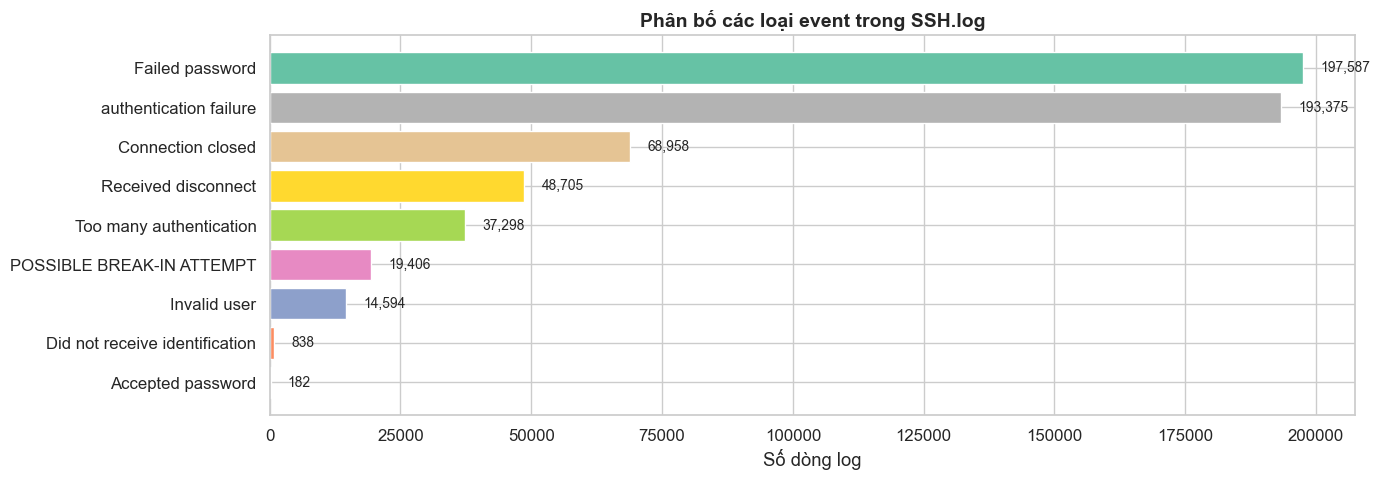

In [3]:
# Visualization: Event type distribution
fig, ax = plt.subplots(figsize=(14, 5))

sorted_events = sorted(event_patterns.items(), key=lambda x: -x[1])
labels = [e[0] for e in sorted_events if e[1] > 0]
values = [e[1] for e in sorted_events if e[1] > 0]
colors = sns.color_palette('Set2', len(labels))

bars = ax.barh(labels[::-1], values[::-1], color=colors)
for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + total_lines * 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Số dòng log')
ax.set_title('Phân bố các loại event trong SSH.log', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# Xem mẫu log
print('=== Mẫu dòng log đầu tiên ===')
with RAW_LOG.open('r', encoding='utf-8', errors='ignore') as f:
    for i, line in enumerate(f):
        if i < 10:
            print(f'  [{i+1}] {line.strip()}')
        else:
            break

print('\n=== Mẫu dòng Accepted password ===')
with RAW_LOG.open('r', encoding='utf-8', errors='ignore') as f:
    count = 0
    for line in f:
        if 'Accepted password' in line and count < 3:
            print(f'  {line.strip()}')
            count += 1

print('\n=== Mẫu dòng message repeated ===')
with RAW_LOG.open('r', encoding='utf-8', errors='ignore') as f:
    count = 0
    for line in f:
        if 'message repeated' in line and count < 3:
            print(f'  {line.strip()}')
            count += 1

=== Mẫu dòng log đầu tiên ===
  [1] Dec 10 06:55:46 LabSZ sshd[24200]: reverse mapping checking getaddrinfo for ns.marryaldkfaczcz.com [173.234.31.186] failed - POSSIBLE BREAK-IN ATTEMPT!
  [2] Dec 10 06:55:46 LabSZ sshd[24200]: Invalid user webmaster from 173.234.31.186
  [3] Dec 10 06:55:46 LabSZ sshd[24200]: input_userauth_request: invalid user webmaster [preauth]
  [4] Dec 10 06:55:46 LabSZ sshd[24200]: pam_unix(sshd:auth): check pass; user unknown
  [5] Dec 10 06:55:46 LabSZ sshd[24200]: pam_unix(sshd:auth): authentication failure; logname= uid=0 euid=0 tty=ssh ruser= rhost=173.234.31.186
  [6] Dec 10 06:55:48 LabSZ sshd[24200]: Failed password for invalid user webmaster from 173.234.31.186 port 38926 ssh2
  [7] Dec 10 06:55:48 LabSZ sshd[24200]: Connection closed by 173.234.31.186 [preauth]
  [8] Dec 10 07:02:47 LabSZ sshd[24203]: Connection closed by 212.47.254.145 [preauth]
  [9] Dec 10 07:07:38 LabSZ sshd[24206]: Invalid user test9 from 52.80.34.196
  [10] Dec 10 07:07:38 LabS


=== Mẫu dòng message repeated ===
  Dec 10 07:13:56 LabSZ sshd[24227]: message repeated 5 times: [ Failed password for root from 5.36.59.76 port 42393 ssh2]
  Dec 10 08:39:59 LabSZ sshd[24408]: message repeated 5 times: [ Failed password for root from 106.5.5.195 port 50719 ssh2]
  Dec 10 11:48:13 LabSZ sshd[28523]: message repeated 5 times: [ Failed password for root from 180.101.249.16 port 53496 ssh2]


### Nhận xét ban đầu

- **655K dòng**, chủ yếu là failure events (Failed password, Invalid user, authentication failure)
- Chỉ **182 dòng** `Accepted password` — dataset gần như toàn traffic tấn công
- **36,967 dòng** `message repeated N times` — parser cần xử lý đặc biệt
- **19,406 dòng** `POSSIBLE BREAK-IN ATTEMPT` — dấu hiệu DNS anomaly
- Thời gian trải qua Dec → Jan → cần xử lý cross-year timestamp

---
## 2. Phát hiện Class Imbalance cực độ

Bước đầu tiên: parse log thô thành records rồi gán nhãn binary (0 = Normal, 1 = Anomaly).
Kết quả cho thấy **99.9% records là anomaly** — mọi classifier trivially đạt 99.9% accuracy.

In [5]:
from log_processing import SSHLogParser
from data_labeling import label_records  # legacy binary labeling

parser = SSHLogParser(year=2023)
records = parser.parse_file(str(RAW_LOG))
print(f'Total records parsed: {len(records):,}')
print(f'Valid users learned: {parser.valid_users}')

Total records parsed: 212,149
Valid users learned: {'xxchen', 'yuewang', 'fztu', 'tzhao', 'jmzhu', 'hxu', 'suyuxin', 'curi', 'zachary'}


C:\Users\phong\AppData\Local\Temp\ipykernel_11488\3998102948.py:28: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\phong\AppData\Local\Temp\ipykernel_11488\3998102948.py:28: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
D:\SSH-anomaly-detection-using-ML\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\SSH-anomaly-detection-using-ML\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


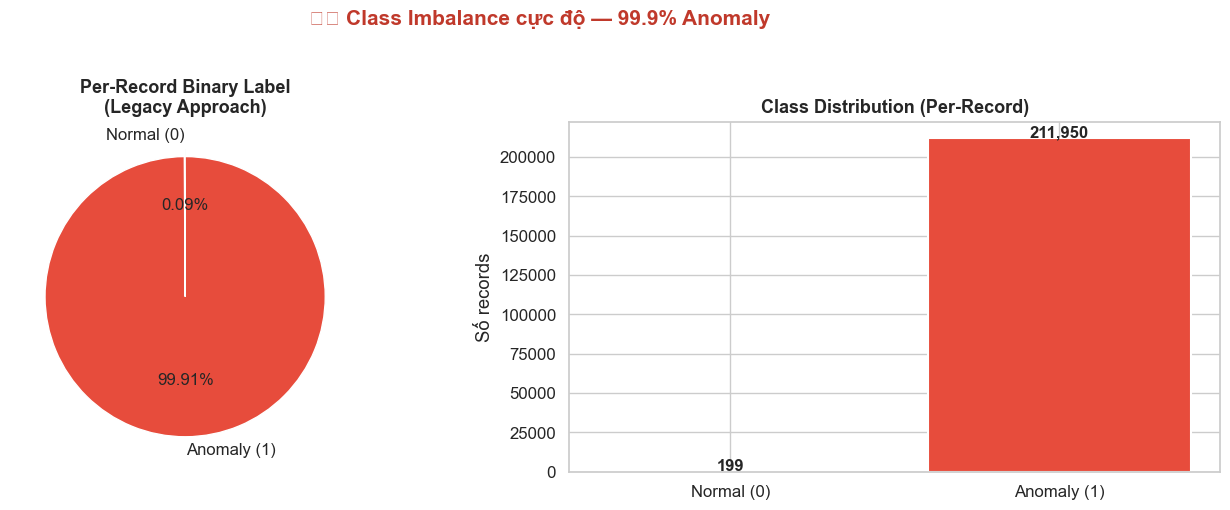

Class 0 (Normal):       199 (0.09%)
Class 1 (Anomaly):  211,950 (99.91%)

→ Mọi classifier chỉ cần predict tất cả = 1 sẽ đạt accuracy 99.9%


In [6]:
# Legacy binary labeling (giữ lại để so sánh)
labeled_legacy = label_records(records)
legacy_dist = Counter(r['class'] for r in labeled_legacy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
ax = axes[0]
labels_pie = ['Normal (0)', 'Anomaly (1)']
sizes = [legacy_dist.get(0, 0), legacy_dist.get(1, 0)]
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0.05, 0)
ax.pie(sizes, explode=explode, labels=labels_pie, colors=colors_pie,
       autopct='%1.2f%%', startangle=90, textprops={'fontsize': 12})
ax.set_title('Per-Record Binary Label\n(Legacy Approach)', fontsize=13, fontweight='bold')

# Bar chart
ax = axes[1]
bars = ax.bar(labels_pie, sizes, color=colors_pie, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Số records')
ax.set_title('Class Distribution (Per-Record)', fontsize=13, fontweight='bold')

plt.suptitle('⚠️ Class Imbalance cực độ — 99.9% Anomaly', fontsize=15,
             fontweight='bold', color='#c0392b', y=1.02)
plt.tight_layout()
plt.show()

print(f'Class 0 (Normal):  {legacy_dist.get(0, 0):>8,} ({legacy_dist.get(0, 0)/len(labeled_legacy)*100:.2f}%)')
print(f'Class 1 (Anomaly): {legacy_dist.get(1, 0):>8,} ({legacy_dist.get(1, 0)/len(labeled_legacy)*100:.2f}%)')
print(f'\n→ Mọi classifier chỉ cần predict tất cả = 1 sẽ đạt accuracy 99.9%')

### Nguyên nhân

1. **Dataset gốc gần như toàn attack traffic** — chỉ 182 success events trong 655K dòng
2. **Binary labeling quá đơn giản** — Rule 1 (`is_valid=0 ∧ is_private=0 ∧ is_failure=1`) bắt gần 100% failure records
3. **Granularity sai** — mỗi dòng log = 1 record, không phản ánh "phiên tấn công"

### Giải pháp

- **Session-level aggregation**: Gom records theo IP + idle gap → giảm từ 212K records xuống ~4K sessions
- **Multi-level labeling**: 5 class (0-4) thay vì binary → class 0 tăng từ 0.1% lên ~3%

---
## 3. Sửa lỗi Parser

Trước khi chuyển sang session approach, cần fix 2 bug trong parser:

### Bug 1: Bỏ sót `message repeated N times`

**36,967 dòng** dạng `message repeated 5 times: [ Failed password for root ...]`
bị parser bỏ qua hoàn toàn. Mỗi dòng = N failure events không được đếm.

**Fix**: Thêm `_parse_repeated()` — trích xuất inner message và count N,
cộng N vào `ip_failure`, `no_failure`, `not_valid_count` thay vì 1.

In [7]:
# Demo: _parse_repeated hoạt động
test_line = 'Dec 10 07:13:56 LabSZ sshd[24227]: message repeated 5 times: [ Failed password for root from 5.36.59.76 port 42393 ssh2]'
inner, count = parser._parse_repeated(test_line)
print(f'Input:  {test_line}')
print(f'Inner:  {inner}')
print(f'Count:  {count}')
print(f'\n→ Dòng này đại diện cho {count} failure events, parser giờ đếm đúng.')

Input:  Dec 10 07:13:56 LabSZ sshd[24227]: message repeated 5 times: [ Failed password for root from 5.36.59.76 port 42393 ssh2]
Inner:  Failed password for root from 5.36.59.76 port 42393 ssh2
Count:  5

→ Dòng này đại diện cho 5 failure events, parser giờ đếm đúng.


### Bug 2: Cross-year timestamp (Dec → Jan)

Log trải từ **Dec 2023 → Jan 2024**, nhưng parser gán cùng `year=2023`.
→ Timestamp tháng 1 < tháng 12 → `td = max(0, ts - prev_ts)` bị clamp về 0.
→ **Mất toàn bộ temporal signal** cho ~50% dataset.

**Fix**: Detect month rollover và auto-increment year.

In [8]:
# Verify cross-year fix
from datetime import datetime

dec_31_ts = int(datetime(2023, 12, 31, 23, 59, 59).timestamp())
jan_records = [r for r in records if int(r['ts']) > dec_31_ts]
jan_nonzero_td = sum(1 for r in jan_records if int(r['td']) > 0)

print(f'Records tháng 1:        {len(jan_records):,}')
print(f'Records có td > 0:      {jan_nonzero_td:,} ({jan_nonzero_td/len(jan_records)*100:.1f}%)')
print(f'\n→ Trước fix: 0% records tháng 1 có td > 0')
print(f'→ Sau fix:   {jan_nonzero_td/len(jan_records)*100:.1f}% — temporal signal được phục hồi')

Records tháng 1:        112,813
Records có td > 0:      108,525 (96.2%)

→ Trước fix: 0% records tháng 1 có td > 0
→ Sau fix:   96.2% — temporal signal được phục hồi


### Bonus: Feature `has_reverse_mapping_failed`

Phát hiện 19,406 dòng `POSSIBLE BREAK-IN ATTEMPT` — dấu hiệu DNS reverse mapping failure.
Đây là cybersecurity context feature rất mạnh, được thêm vào parser.

In [9]:
rm_records = sum(1 for r in records if int(r.get('is_reverse_mapping_failed', 0)) == 1)
rm_ips = len(parser._reverse_mapping_ips)
print(f'Unique IPs with reverse mapping failure: {rm_ips}')
print(f'Records flagged is_reverse_mapping_failed=1: {rm_records:,} / {len(records):,}')

Unique IPs with reverse mapping failure: 262
Records flagged is_reverse_mapping_failed=1: 27,284 / 212,149


---
## 4. Session-level Aggregation + Multi-level Labels

**Ý tưởng**: Thay vì 1 record = 1 dòng log, gom thành 1 record = 1 session
(nhóm theo IP, tách bằng idle gap 10 phút).

**5 class thay vì binary:**

| Class | Tên | Định nghĩa |
|-------|-----|------------|
| 0 | Normal | Tất cả success |
| 1 | Single failure | Failure đơn lẻ, không pattern |
| 2 | Scan | Dò nhiều username khác nhau |
| 3 | Brute-force | Tấn công dồn dập (streak > 5) |
| 4 | Break-in | Success sau failure (cùng username) |

In [10]:
from data_labeling import build_session_dataset, write_session_csv
from feature_engineering import CLASS_NAMES

dataset = build_session_dataset(records)
print(f'212,149 records → {len(dataset):,} sessions (giảm {len(records)/len(dataset):.0f}x)')

212,149 records → 3,916 sessions (giảm 54x)


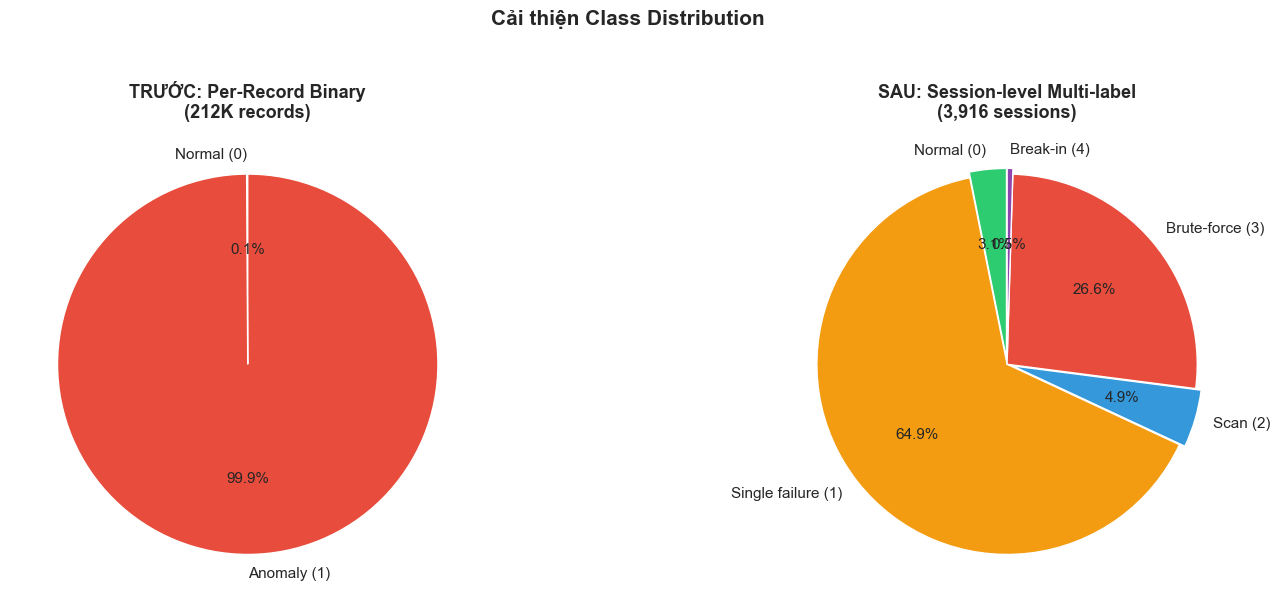

In [11]:
# Class distribution comparison: Legacy vs Session
session_dist = Counter(r['class'] for r in dataset)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Legacy (binary)
ax = axes[0]
legacy_labels = ['Normal (0)', 'Anomaly (1)']
legacy_sizes = [legacy_dist.get(0, 0), legacy_dist.get(1, 0)]
legacy_colors = ['#2ecc71', '#e74c3c']
ax.pie(legacy_sizes, labels=legacy_labels, colors=legacy_colors,
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title('TRƯỚC: Per-Record Binary\n(212K records)', fontsize=13, fontweight='bold')

# Session (multi-level)
ax = axes[1]
session_colors = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c', '#8e44ad']
session_labels = [f'{CLASS_NAMES[i]} ({i})' for i in range(5)]
session_sizes = [session_dist.get(i, 0) for i in range(5)]
# Explode small slices
explode = [0.03 if s/sum(session_sizes) < 0.05 else 0 for s in session_sizes]
ax.pie(session_sizes, labels=session_labels, colors=session_colors,
       explode=explode, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title(f'SAU: Session-level Multi-label\n({len(dataset):,} sessions)', fontsize=13, fontweight='bold')

plt.suptitle('Cải thiện Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Detailed distribution table
print(f'{"Class":<8} {"Label":<18} {"Count":>8} {"Percent":>10}')
print('-' * 48)
for cls in range(5):
    count = session_dist.get(cls, 0)
    pct = count / len(dataset) * 100
    print(f'{cls:<8} {CLASS_NAMES[cls]:<18} {count:>8,} {pct:>9.2f}%')
print('-' * 48)
print(f'{"Total":<8} {"":<18} {len(dataset):>8,} {100:>9.2f}%')

print(f'\n✅ Class 0 (Normal): 0.1% → {session_dist.get(0,0)/len(dataset)*100:.1f}% (cải thiện ~30x)')

Class    Label                 Count    Percent
------------------------------------------------
0        Normal                  123      3.14%
1        Single failure        2,542     64.91%
2        Scan                    192      4.90%
3        Brute-force           1,040     26.56%
4        Break-in                 19      0.49%
------------------------------------------------
Total                          3,916    100.00%

✅ Class 0 (Normal): 0.1% → 3.1% (cải thiện ~30x)


---
## 5. Tinh chỉnh ngưỡng gán nhãn

Sau lần implement đầu, phát hiện 3 vấn đề và fix lần lượt:

### Fix 1: Scan (class 2) gần như biến mất

**Vấn đề**: Ngưỡng `unique_users >= 4` quá cao khi session bị idle-gap tách ngắn.
Chỉ 2 sessions đạt ngưỡng.

**Fix**: Hạ xuống `unique_users >= 2 AND unique_users_ratio > 0.5 AND total >= 2`.
Kết quả: 2 → **192 sessions** scan.

### Fix 2: Break-in (class 4) false positive

**Vấn đề**: Session có 2 events từ 2 user khác nhau (1 scan + 1 valid login)
bị gán class 4 vì "có success sau failure".

**Fix**: Yêu cầu success phải cùng username với failure trước đó.
Kết quả: 20 → **19 sessions** (loại 1 false positive).

### Fix 3: `no_failure` / `max_not_valid_count` cross-session leakage

**Vấn đề**: Parser tính `no_failure` và `not_valid_count` per-IP cumulative.
Giá trị bị "lây" từ session trước sang session sau của cùng IP.

**Fix**:
- `max_no_failure` → **`max_failure_streak`**: tính consecutive failure streak nội trong session
- `max_not_valid_count` → **`invalid_user_attempts`**: đếm số failure vào user không hợp lệ trong session

Brute-force giảm từ 2,718 → **1,040** sessions (loại bỏ sessions bị inflate).

---
## 6. Đánh giá Dataset cuối cùng

Load session CSV đã qua toàn bộ pipeline fix.

In [13]:
from feature_engineering import load_session_csv, prepare_features, describe_features, TRAINING_FEATURES

# Regenerate & save
write_session_csv(dataset, str(SESSION_CSV))

df = load_session_csv(SESSION_CSV)
print(f'Shape: {df.shape}')
df.head(10)

Shape: (3916, 19)


,ip,is_private,total_attempts,session_duration,attempts_per_second,is_single_event,total_failures,total_successes,failure_ratio,unique_users_count,unique_users_ratio,has_root_attempt,has_valid_user_attempt,max_failure_streak,invalid_user_attempts,has_reverse_mapping_failed,ts_first,ts_last,class
0,173.234.31.186,0,2,2,0.666667,0,2,0,1.0,1,0.5,0,0,2,2,1,1702166146,1702166148,1
1,173.234.31.186,0,2,2,0.666667,0,2,0,1.0,1,0.5,0,0,2,2,1,1702166908,1702166910,1
2,52.80.34.196,0,2,7,0.250000,0,2,0,1.0,1,0.5,0,0,2,2,0,1702166858,1702166865,1
3,52.80.34.196,0,2,7,0.250000,0,2,0,1.0,1,0.5,0,0,2,2,0,1702169755,1702169762,1
4,52.80.34.196,0,2,7,0.250000,0,2,0,1.0,1,0.5,0,0,2,2,0,1702172660,1702172667,1
5,52.80.34.196,0,2,7,0.250000,0,2,0,1.0,1,0.5,0,0,2,2,0,1702175555,1702175562,1
6,52.80.34.196,0,2,8,0.222222,0,2,0,1.0,1,0.5,0,0,2,2,0,1702178461,1702178469,1
7,52.80.34.196,0,2,7,0.250000,0,2,0,1.0,1,0.5,0,0,2,2,0,1702181380,1702181387,1
8,52.80.34.196,0,2,2,0.666667,0,2,0,1.0,1,0.5,0,0,2,2,0,1702184293,1702184295,1
9,52.80.34.196,0,2,7,0.250000,0,2,0,1.0,1,0.5,0,0,2,2,0,1702187209,1702187216,1


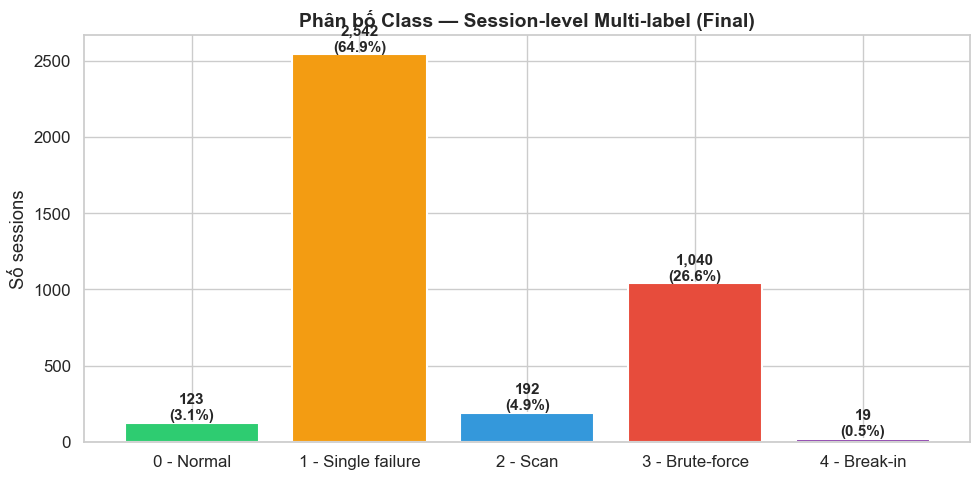

In [14]:
# Class distribution bar chart (final)
fig, ax = plt.subplots(figsize=(10, 5))

class_colors = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c', '#8e44ad']
class_labels = [f'{i} - {CLASS_NAMES[i]}' for i in range(5)]
class_counts = [session_dist.get(i, 0) for i in range(5)]

bars = ax.bar(class_labels, class_counts, color=class_colors,
              edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, class_counts):
    pct = count / len(dataset) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Số sessions')
ax.set_title('Phân bố Class — Session-level Multi-label (Final)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Feature engineering
X, y = prepare_features(df)
print(f'Feature matrix: {X.shape}')
print(f'Features ({len(TRAINING_FEATURES)}): {TRAINING_FEATURES}')
print(f'\nTarget distribution:')
print(y.value_counts().sort_index())

Feature matrix: (3916, 11)
Features (11): ['is_private', 'session_duration', 'attempts_per_second', 'is_single_event', 'failure_ratio', 'unique_users_ratio', 'has_root_attempt', 'has_valid_user_attempt', 'max_failure_streak', 'invalid_user_attempts', 'has_reverse_mapping_failed']

Target distribution:
class
0     123
1    2542
2     192
3    1040
4      19
Name: count, dtype: int64


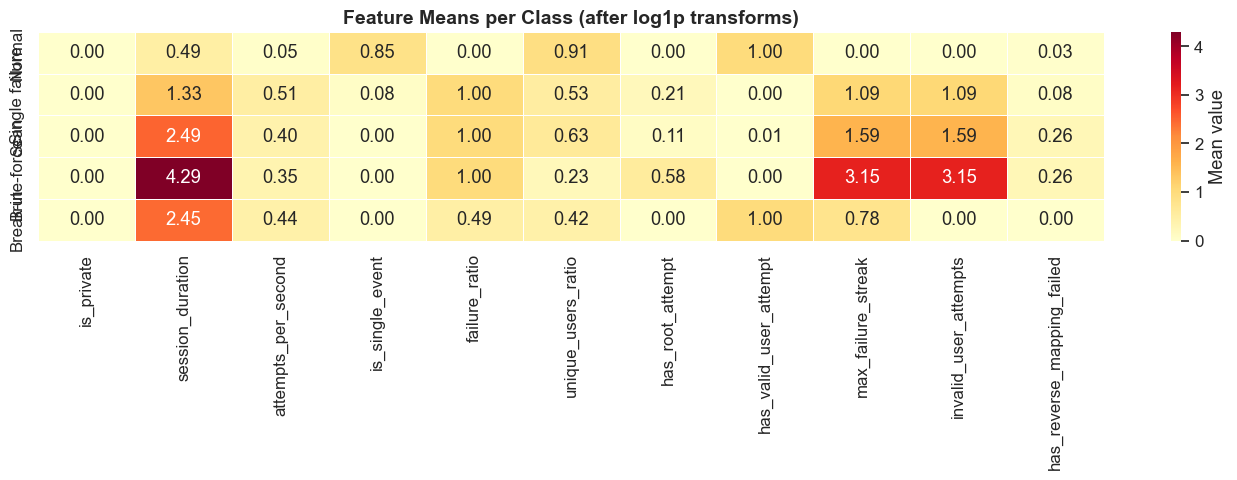

In [16]:
# Feature statistics per class
summary = describe_features(X, y)

# Heatmap of mean feature values per class
mean_cols = [c for c in summary.columns if c.endswith('_mean')]
heatmap_data = summary.set_index('label')[mean_cols]
heatmap_data.columns = [c.replace('_mean', '') for c in mean_cols]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean value'})
ax.set_title('Feature Means per Class (after log1p transforms)', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

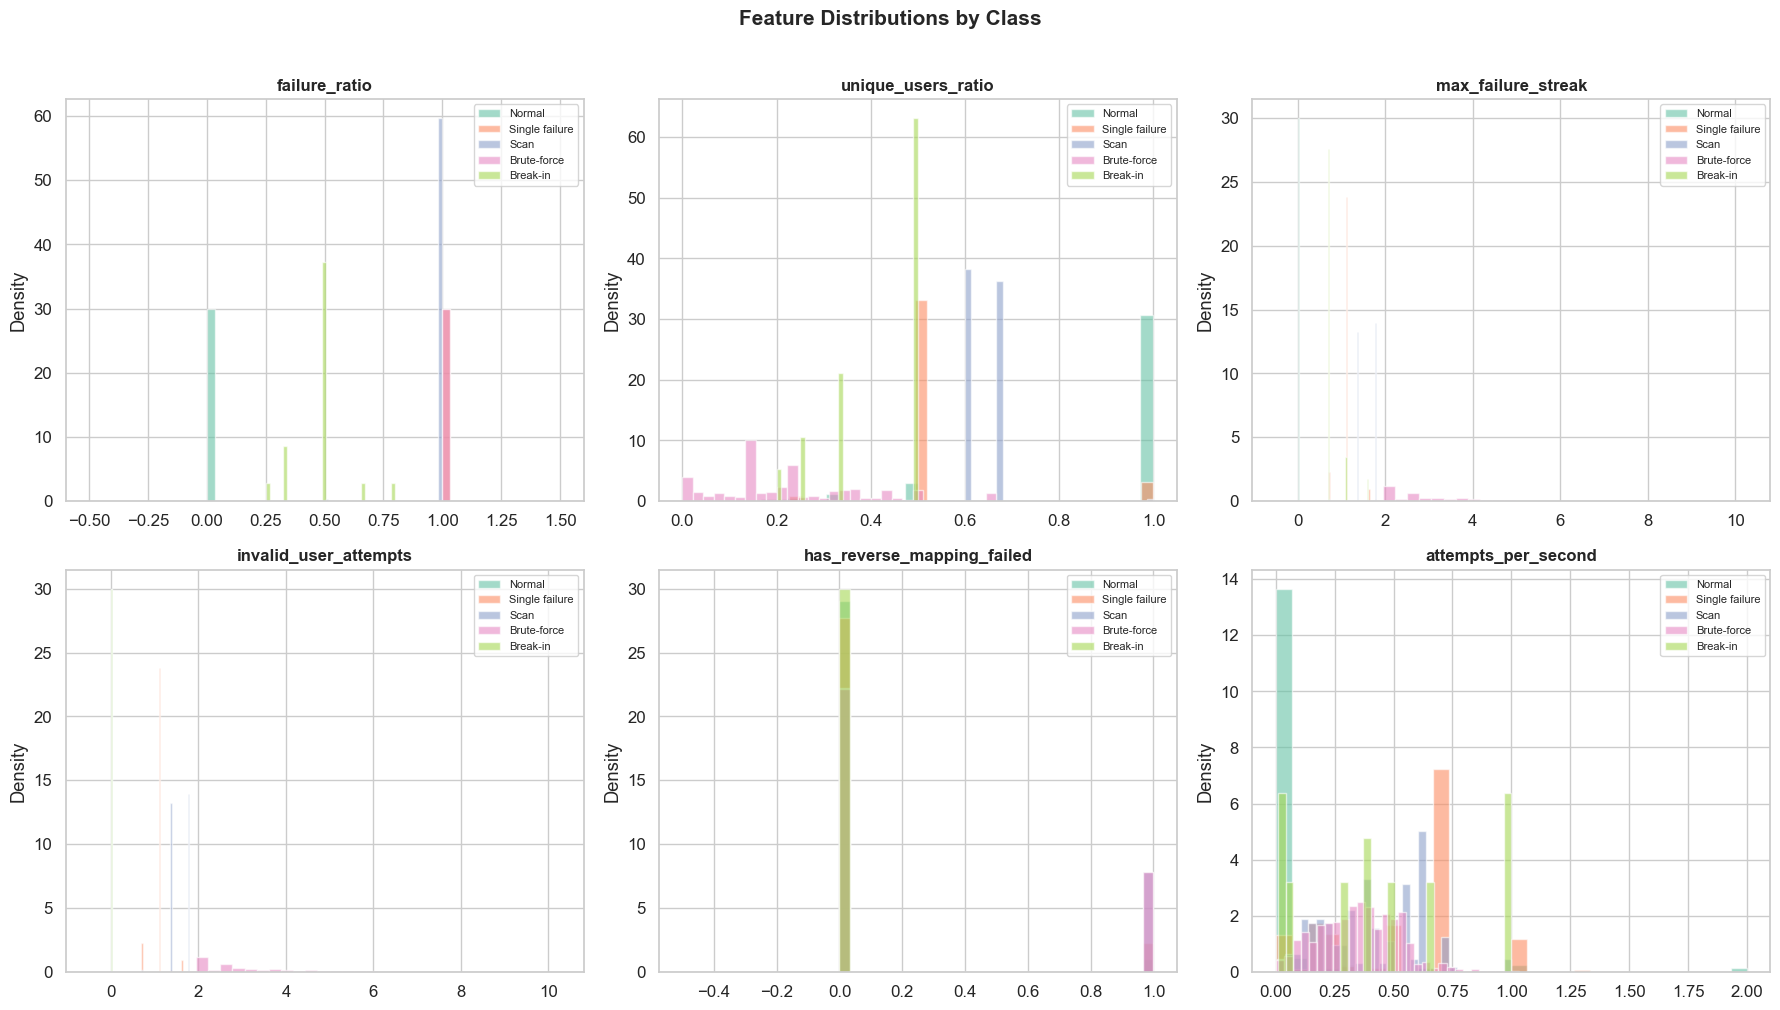

In [17]:
# Key feature distributions by class
key_features = ['failure_ratio', 'unique_users_ratio', 'max_failure_streak',
                'invalid_user_attempts', 'has_reverse_mapping_failed', 'attempts_per_second']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

combined = X.copy()
combined['class_name'] = y.map(CLASS_NAMES)

for i, feat in enumerate(key_features):
    ax = axes[i]
    for cls_idx, cls_name in CLASS_NAMES.items():
        subset = combined[combined['class_name'] == cls_name][feat]
        if len(subset) > 0:
            ax.hist(subset, bins=30, alpha=0.6, label=cls_name, density=True)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions by Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

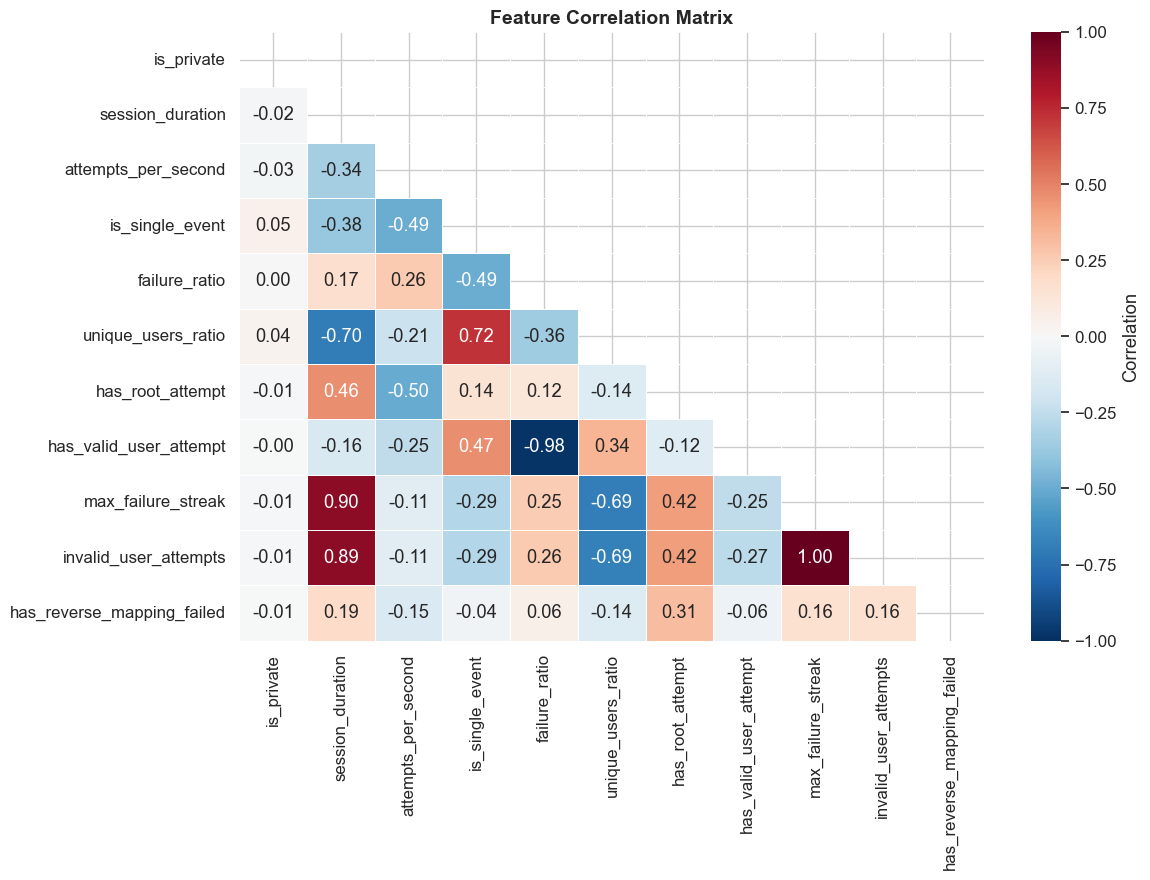

Feature pairs with |correlation| > 0.5:
  max_failure_streak ↔ invalid_user_attempts: 0.999
  failure_ratio ↔ has_valid_user_attempt: -0.982
  session_duration ↔ max_failure_streak: 0.898
  session_duration ↔ invalid_user_attempts: 0.894
  is_single_event ↔ unique_users_ratio: 0.722
  session_duration ↔ unique_users_ratio: -0.702
  unique_users_ratio ↔ max_failure_streak: -0.690
  unique_users_ratio ↔ invalid_user_attempts: -0.687
  attempts_per_second ↔ has_root_attempt: -0.502


In [18]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(12, 9))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Highlight high correlations
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.5:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr:
    print('Feature pairs with |correlation| > 0.5:')
    for f1, f2, c in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {f1} ↔ {f2}: {c:.3f}')
else:
    print('Không có cặp feature nào có |correlation| > 0.5 — features độc lập tốt.')

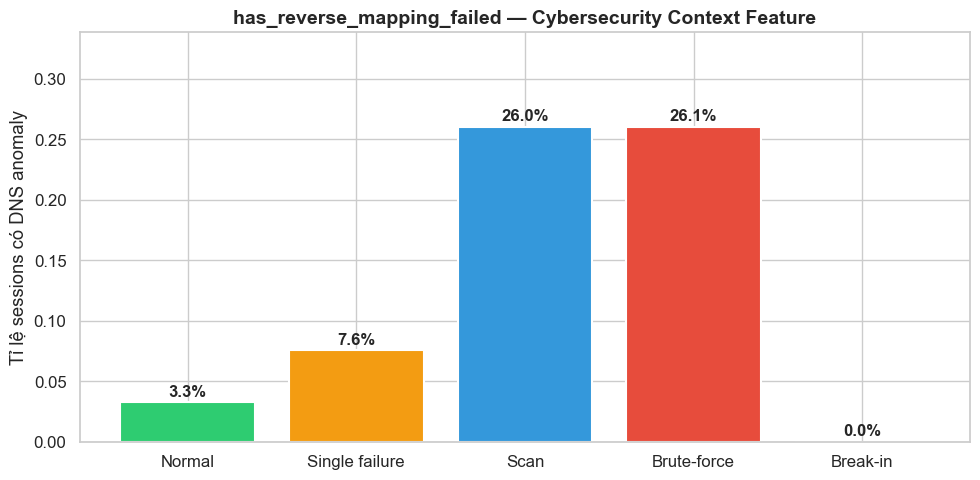

→ Normal (3%) vs Scan/Brute-force (26%) — signal phân biệt mạnh
→ Break-in = 0% — attacker đoán đúng password thường dùng IP sạch


In [19]:
# has_reverse_mapping_failed discriminative power
fig, ax = plt.subplots(figsize=(10, 5))

rm_by_class = {}
for cls in range(5):
    subset = X[y == cls]
    rm_by_class[CLASS_NAMES[cls]] = subset['has_reverse_mapping_failed'].mean()

bars = ax.bar(rm_by_class.keys(), rm_by_class.values(), color=class_colors,
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, rm_by_class.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Tỉ lệ sessions có DNS anomaly')
ax.set_title('has_reverse_mapping_failed — Cybersecurity Context Feature',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(rm_by_class.values()) * 1.3)
plt.tight_layout()
plt.show()

print('→ Normal (3%) vs Scan/Brute-force (26%) — signal phân biệt mạnh')
print('→ Break-in = 0% — attacker đoán đúng password thường dùng IP sạch')

---
## 7. Tổng kết

### Hành trình xử lý dữ liệu

| Bước | Vấn đề | Giải pháp | Kết quả |
|------|--------|-----------|----------|
| Raw parsing | Bỏ sót `message repeated` | `_parse_repeated()` + count N | +37K failure events |
| Raw parsing | Cross-year timestamp | Month rollover detection | 96% records Jan có td > 0 |
| Raw parsing | Thiếu DNS signal | `has_reverse_mapping_failed` | 262 IPs, 517 sessions flagged |
| Labeling | 99.9% anomaly (binary) | Session aggregation + multi-level | 5 classes, 3.1% Normal |
| Labeling | Scan class = 2 sessions | Hạ ngưỡng scan, dùng ratio | 192 sessions |
| Labeling | Break-in false positive | Same-user requirement | -1 false positive |
| Features | `no_failure` cross-session | `max_failure_streak` per-session | Brute-force: 2,718 → 1,040 |
| Features | `not_valid_count` inflated | `invalid_user_attempts` per-session | Clean per-session count |

### Dataset cuối cùng

- **3,916 sessions** với **11 features** sạch
- **5 class labels**: Normal, Single failure, Scan, Brute-force, Break-in
- Không có label leakage (drop `total_failures`, `total_successes`)
- Không có cross-session leakage (streak + invalid users tính per-session)
- Feature cybersecurity context: `has_reverse_mapping_failed`
- Sẵn sàng cho ML training với `class_weight='balanced'`

In [20]:
# Final summary statistics
print('=' * 60)
print('DATASET SUMMARY')
print('=' * 60)
print(f'Sessions:  {len(dataset):,}')
print(f'Features:  {X.shape[1]}')
print(f'Classes:   {len(y.unique())}\n')

for cls in range(5):
    count = (y == cls).sum()
    pct = count / len(y) * 100
    print(f'  {cls} {CLASS_NAMES[cls]:17s}: {count:>5,} ({pct:5.2f}%)')

print(f'\nFeature list:')
for i, feat in enumerate(X.columns, 1):
    dtype = 'binary' if X[feat].nunique() <= 2 else 'continuous'
    print(f'  {i:2d}. {feat:30s} [{dtype}]')

print(f'\n→ Saved to: {SESSION_CSV}')

DATASET SUMMARY
Sessions:  3,916
Features:  11
Classes:   5

  0 Normal           :   123 ( 3.14%)
  1 Single failure   : 2,542 (64.91%)
  2 Scan             :   192 ( 4.90%)
  3 Brute-force      : 1,040 (26.56%)
  4 Break-in         :    19 ( 0.49%)

Feature list:
   1. is_private                     [binary]
   2. session_duration               [continuous]
   3. attempts_per_second            [continuous]
   4. is_single_event                [binary]
   5. failure_ratio                  [continuous]
   6. unique_users_ratio             [continuous]
   7. has_root_attempt               [binary]
   8. has_valid_user_attempt         [binary]
   9. max_failure_streak             [continuous]
  10. invalid_user_attempts          [continuous]
  11. has_reverse_mapping_failed     [binary]

→ Saved to: ..\data\processed\ssh_sessions.csv
